In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

In [2]:
data_frame = pd.read_csv('airline-passengers.csv')
timeseries = data_frame[["Passengers"]].values.astype('float32')

In [3]:
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

In [4]:
def create_dataset(dataset, lookback):
  X, y = [], []
  for i in range(len(dataset) - lookback):
    feature = dataset[i:i+lookback]
    target = dataset[i+1:i+lookback+1]
    X.append(feature)
    y.append(target)
  return torch.tensor(X), torch.tensor(y)

In [5]:
lookback = 4
X_train, y_train = create_dataset(train, lookback)
X_test, y_test = create_dataset(test, lookback)

/tmp/ipykernel_11233/31327553.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(X), torch.tensor(y)


In [15]:
class AirModel(nn.Module):
  def __init__(self):
    super(AirModel, self).__init__()
    self.lstm = nn.LSTM(input_size=1, hidden_size=50, num_layers=1, batch_first=True)
    self.linear = nn.Linear(50, 1)

  def forward(self, x):
    x, _ = self.lstm(x)
    x = self.linear(x)
    return x

In [16]:
model = AirModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle=True, batch_size=8)
n_epochs = 2000

In [17]:
for epoch in range(n_epochs):
  model.train()
  for X_batch, y_batch in loader:
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  if epoch % 100 != 0:
    continue
  model.eval()
  with torch.no_grad():
    y_pred = model(X_train)
    train_rmse = np.sqrt(loss_fn(y_pred, y_train))
    y_pred = model(X_test)
    test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

/tmp/ipykernel_11233/50227955.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  train_rmse = np.sqrt(loss_fn(y_pred, y_train))
/tmp/ipykernel_11233/50227955.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  test_rmse = np.sqrt(loss_fn(y_pred, y_test))


Epoch 0: train RMSE 225.8029, test RMSE 425.0278
Epoch 100: train RMSE 175.6674, test RMSE 372.4029
Epoch 200: train RMSE 136.5867, test RMSE 329.3990
Epoch 300: train RMSE 106.1827, test RMSE 292.4875
Epoch 400: train RMSE 83.3436, test RMSE 260.4838
Epoch 500: train RMSE 64.2839, test RMSE 229.7144
Epoch 600: train RMSE 50.8772, test RMSE 203.1071
Epoch 700: train RMSE 41.1835, test RMSE 179.8406
Epoch 800: train RMSE 34.4300, test RMSE 159.3415
Epoch 900: train RMSE 29.7294, test RMSE 141.7461
Epoch 1000: train RMSE 26.5885, test RMSE 127.2072
Epoch 1100: train RMSE 24.5684, test RMSE 115.6188
Epoch 1200: train RMSE 23.2212, test RMSE 106.0620
Epoch 1300: train RMSE 22.1694, test RMSE 99.2386
Epoch 1400: train RMSE 21.3356, test RMSE 93.3678
Epoch 1500: train RMSE 21.0202, test RMSE 88.3853
Epoch 1600: train RMSE 20.5121, test RMSE 85.3177
Epoch 1700: train RMSE 20.0988, test RMSE 81.3449
Epoch 1800: train RMSE 19.6145, test RMSE 78.9315
Epoch 1900: train RMSE 19.7011, test RMSE 76.

In [18]:
with torch.no_grad():
  train_plot = np.ones_like(timeseries) * np.nan
  y_pred = model(X_train)
  y_pred = y_pred[: -1, :]
  train_plot[lookback:train_size] = model(X_train)[:, -1, :]
  test_plot = np.ones_like(timeseries) * np.nan
  test_plot[train_size + lookback:len(timeseries)] = model(X_test)[:, -1, :]

/tmp/ipykernel_11233/1897213625.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  train_plot[lookback:train_size] = model(X_train)[:, -1, :]
/tmp/ipykernel_11233/1897213625.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  test_plot[train_size + lookback:len(timeseries)] = model(X_test)[:, -1, :]


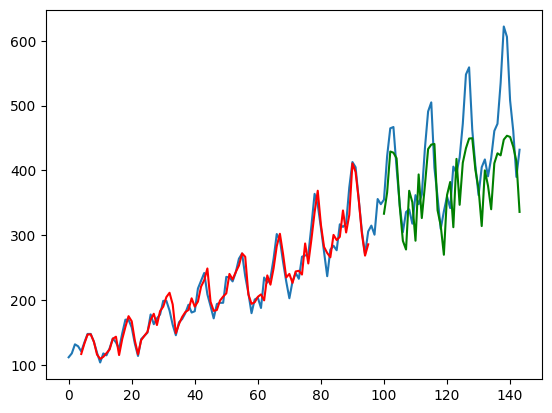

In [19]:
plt.plot(timeseries)
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()